# 데이터 로드



In [3]:
import pandas as pd

file_path = '/Users/junhapark/data-science-workspace/notes/text-mining/sentiment labelled sentences/yelp_labelled.txt'
data = pd.read_csv(file_path, names=['text', 'sentiment'], sep='\t')

data.head()

,text,sentiment
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [4]:
sentiment_counts = data['sentiment'].value_counts()
print(sentiment_counts)

sentiment
1    500
0    500
Name: count, dtype: int64


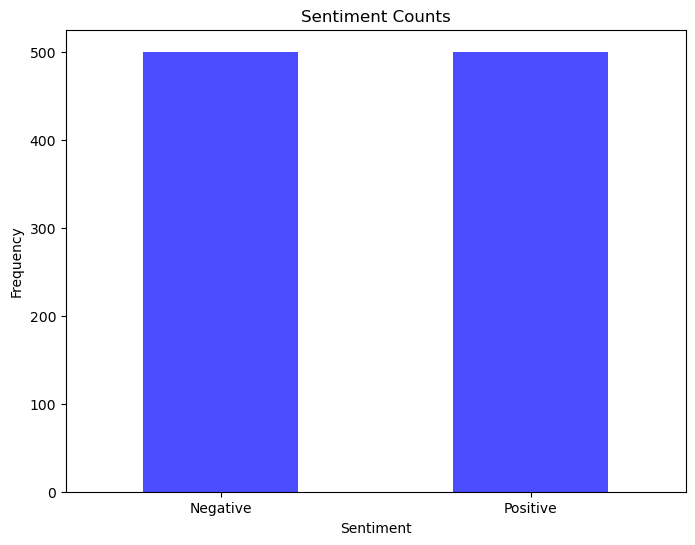

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Sentiment Counts')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.xticks([0, 1], ['Negative', 'Positive'], rotation=0)
plt.show()

# 전처리 (Tokenize, Stop Words + alpha)

In [6]:
# 예시 문장 임의로 선택
example_text = data['text'][0]
print(example_text)

Wow... Loved this place.


In [7]:
# 소문자로 통일
example_text = example_text.lower()
print(example_text)

wow... loved this place.


In [ ]:
# 비 단어적 요소 제거
# re 패키지 이용
# re - 'regular expression'
# \w는 단어가 아닌 것을 칭한다. 띄어쓰기로 변환 

import re

example_text = re.sub(r'\W', ' ', example_text)
print(example_text)

wow    loved this place 


In [ ]:
# tokenize 적용
example_text = example_text.split() #default 띄어쓰기 단위로 
print(example_text)


# split()은 문자열을 특정 구분자 기준으로 여러 부분 문자열로 나눈 뒤, 
# 그 결과를 파이썬 list 객체로 반환하는 메서드다.

['wow', 'loved', 'this', 'place']


In [ ]:
# stop words 제거
import nltk # Natural Language Toolkit 
from nltk.corpus import stopwords
# nltk.corpus.stopwords를 이용해서 영어 불용어 목록을 가져옴 

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/junhapark/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
type(stopwords.words('english'))

list

In [ ]:
example_text = [text for text in example_text if text not in stop_words]
print(example_text)
# example_text의 각 단어를 순회하면서
# stop_words에 포함되지 않은 단어만 남겨 새 리스트로 저장한다.

['wow', 'loved', 'place']


In [ ]:
# 최종 함수로 표현
# 여러 전처리 과정을 preprocessing 함수로 정의
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocessing(text) :
    text = text.lower() # 소문자로 변환
    text = re.sub(r'\W', ' ', text) # 단어가 아닌것들은 ' '로 대체
    text = text.split() # 문장을 단어로 tokenize
    text = [t for t in text if t not in stop_words] # stop_words를 제외하고 재구성
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/junhapark/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
print(preprocessing(data['text'][0]))

['wow', 'loved', 'place']


In [ ]:
# 기존 데이터 프레임 업데이트
# apply 함수 사용
# preprocessing 함수를 각 문장에 적용한 결과를 preprocessed 열에 저장한다.

data['preprocessed'] = data['text'].apply(preprocessing)
data.head()

,text,sentiment,preprocessed
0,Wow... Loved this place.,1,"[wow, loved, place]"
1,Crust is not good.,0,"[crust, good]"
2,Not tasty and the texture was just nasty.,0,"[tasty, texture, nasty]"
3,Stopped by during the late May bank holiday of...,1,"[stopped, late, may, bank, holiday, rick, stev..."
4,The selection on the menu was great and so wer...,1,"[selection, menu, great, prices]"


# 문장의 임베딩 구하기

## GloVe 적용

In [ ]:
from gensim.downloader import load

# 너무 큰 차원은 시간이 오려걸려 100 차원으로 로드 진행
# 약 2분 소요
glove = load('glove-wiki-gigaword-100')

# gensim.downloader로 불러온 glove-wiki-gigaword-100은
# 이미 대규모 말뭉치로 학습된 GloVe 임베딩 모델이며,
# 특정 단어를 입력하면 그 단어에 해당하는 사전학습된 100차원 임베딩 벡터를 찾아 반환한다.




In [37]:
type(data['preprocessed'][0])

list

In [16]:
preprocessed_word = data['preprocessed'][0]

for word in preprocessed_word :
    print(word, glove[word])

wow [ 3.3134e-02  3.9436e-01  7.1448e-01 -1.1337e+00 -7.2332e-01 -3.8481e-01
  5.0780e-01 -1.4907e-01  6.6017e-01 -1.0201e-01  9.6231e-01  1.1387e-03
 -1.3263e-01  4.5797e-02  2.7135e-01 -3.2550e-01 -3.9210e-01  6.5267e-01
 -2.4488e-01  6.0425e-01  4.6606e-01  2.0726e-01 -4.5639e-01 -4.7955e-01
  3.5442e-01  1.3614e+00  6.4953e-02  5.8670e-01  3.8000e-01 -6.9888e-01
 -9.8310e-03  4.4655e-01  3.2409e-01  7.0773e-01 -1.6529e-01  1.4208e-01
 -1.0592e-01  3.4966e-01  4.9768e-01 -1.3657e+00  5.9729e-02  8.9261e-01
 -5.1973e-02 -2.3988e-01 -2.6148e-01 -4.6569e-01  3.8102e-01 -2.2734e-02
  6.7690e-02 -5.2129e-01 -1.0081e+00  3.2135e-01  1.3263e-02 -3.2060e-01
 -1.2772e+00 -9.8548e-01  5.2983e-01 -6.2298e-02  2.2495e-01 -2.6118e-03
 -6.1793e-01  9.9997e-01 -1.0703e+00  2.0964e-01  2.2643e-01  4.3646e-01
  3.7288e-01  4.4264e-01  1.9080e-01  2.0068e-01  9.2300e-01 -4.9012e-02
 -1.2524e-01 -4.6946e-01  4.9879e-02  7.7502e-01  7.5118e-01 -6.8137e-01
  6.9687e-01 -7.6334e-01  1.3828e-01 -7.7210e-0

## TF-IDF 적용

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform([' '.join(doc) for doc in data['preprocessed']]) # 모든 문장을 모아 하나의 큰 문서 덩어리를 생성
tfidf_feature_names = vectorizer.get_feature_names_out()

In [41]:
tfidf_feature_names

array(['00', '10', '100', ..., 'yum', 'yummy', 'zero'],
      shape=(1909,), dtype=object)

In [42]:
import numpy as np
np.where(tfidf_feature_names == 'wow')[0][0]

np.int64(1889)

In [43]:
for word in preprocessed_word :
    doc_idx = 0 # 0 : 원래 문서의 0번째 문장이므로
    word_idx = np.where(tfidf_feature_names == word)[0][0] # 단어 집합으로부터 word의 위치를 찾아냄

    value = tfidf_matrix.toarray()[doc_idx][word_idx]
    # toarray() : tf-idf matrix가 0이 많은 sparse matrix여서 이를 원래 0과 숫자값으로 이루어진 형태로 변환

    print(f'{word}의 tf-idf 값 : {value:.4f}')

wow의 tf-idf 값 : 0.7135
loved의 tf-idf 값 : 0.6028
place의 tf-idf 값 : 0.3571


## 함수로 표현

In [44]:
import numpy as np

def sentence_embedding(tfidf_matrix, tfidf_feature_names, doc, doc_idx):
    embeddings = []
    for word in doc:
        # GloVe에서 학습한 데이터와 tf-idf에서 학습한 데이터만 취급
        # 그렇지 않은 데이터는 무시됨
        if word in glove and word in tfidf_feature_names:
            # 여기서는 transform을 쓰지 않고 이미 학습한 matrix에서 indexing으로 가져옴
            # 속도 효율성이 높음
            # 만약 처음 보는 문장에 대해서 TF-IDF를 한다면 transform이 필수!
            word_idx = np.where(tfidf_feature_names==word)[0][0]
            tfidf_weight = tfidf_matrix.toarray()[doc_idx, word_idx]

            embeddings.append(glove[word] * tfidf_weight)
    return np.mean(embeddings, axis=0) if embeddings else np.zeros(100)  # GloVe 차원에 맞춰 조정

In [46]:
preprocessed_word

['wow', 'loved', 'place']

In [47]:
sentence_embedding(tfidf_matrix, tfidf_feature_names, preprocessed_word, 0) # 예시 문장은 0번째 위치의 문장!

array([ 0.0166593 ,  0.23227139,  0.21521084, -0.30236791, -0.2852808 ,
        0.09835948,  0.05447771, -0.07844365,  0.12750282, -0.06023952,
        0.28007465,  0.11944699,  0.07260193, -0.07175703, -0.03128211,
       -0.19379974,  0.06767367,  0.21205733, -0.25992267,  0.43483154,
        0.1444536 ,  0.13265453, -0.03620066, -0.26992651,  0.19761361,
        0.30385763, -0.08506642,  0.05645426,  0.24448217, -0.16316617,
       -0.00325877,  0.19798256,  0.16366552,  0.25050273, -0.01592364,
        0.10984685, -0.10182228,  0.23466536,  0.13963213, -0.49488542,
       -0.04828039,  0.12436902,  0.10708094, -0.19833356, -0.11882915,
       -0.01156989,  0.1161475 ,  0.05549104,  0.12373926, -0.3981682 ,
       -0.17899461,  0.06053012,  0.00293016,  0.21120745, -0.3819191 ,
       -0.81201751,  0.10945544,  0.07927296,  0.23233421,  0.09520606,
       -0.23621699,  0.6604558 , -0.33795806, -0.08933164,  0.21102961,
        0.07969924,  0.23234274,  0.19219715, -0.0248637 , -0.05

In [48]:
# 문장 임베딩 값을 새로운 열로 저장
# 여러 입력을 넣어주기 위해 lambda 함수를 활용하고
# 특정 행을 의미하는 row를 이용해 행 번호를 넣어줌 (row.name)
data['sentence_emb'] = data.apply(lambda row: sentence_embedding(tfidf_matrix,
                                                                 tfidf_feature_names,
                                                                 row['preprocessed'],
                                                                 row.name), axis=1)
data.head()

,text,sentiment,preprocessed,sentence_emb
0,Wow... Loved this place.,1,"[wow, loved, place]","[0.016659300016110015, 0.23227138910401346, 0...."
1,Crust is not good.,0,"[crust, good]","[-0.45803147025590357, 0.2397445190558245, 0.3..."
2,Not tasty and the texture was just nasty.,0,"[tasty, texture, nasty]","[-0.31745906546836616, 0.21565543314636718, 0...."
3,Stopped by during the late May bank holiday of...,1,"[stopped, late, may, bank, holiday, rick, stev...","[-0.007096235739999682, -0.1248404635563073, 0..."
4,The selection on the menu was great and so wer...,1,"[selection, menu, great, prices]","[-0.04557724395785125, 0.13483182971370886, 0...."


# 로지스틱 회귀 모델 학습 및 평가

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = np.stack(data['sentence_emb'].values)
y = np.stack(data['sentiment'].values)

# 훈련 데이터와 테스트 데이터로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
X_train

array([[-0.26887371,  0.16385811,  0.36850359, ...,  0.03234626,
         0.22914057, -0.10332172],
       [ 0.0289532 ,  0.02608283,  0.12037811, ..., -0.17071883,
         0.11515227,  0.03565452],
       [-0.09933347,  0.07719884,  0.01101922, ...,  0.11057529,
         0.17954359,  0.05213454],
       ...,
       [-0.0542071 ,  0.00744642,  0.16055353, ..., -0.06578694,
         0.09308693,  0.25996951],
       [-0.03125957,  0.13235997,  0.10777359, ..., -0.21225671,
         0.10834097, -0.07275223],
       [-0.08099845,  0.07412213,  0.17458347, ..., -0.0626343 ,
         0.24830177,  0.06297495]], shape=(800, 100))

In [51]:
y_train

array([0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,

In [52]:
# 로지스틱 회귀 모델 생성 및 학습
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [53]:
# 학습 결과 확인을 위해 검증 데이터 추론 진행
predictions = model.predict(X_test)

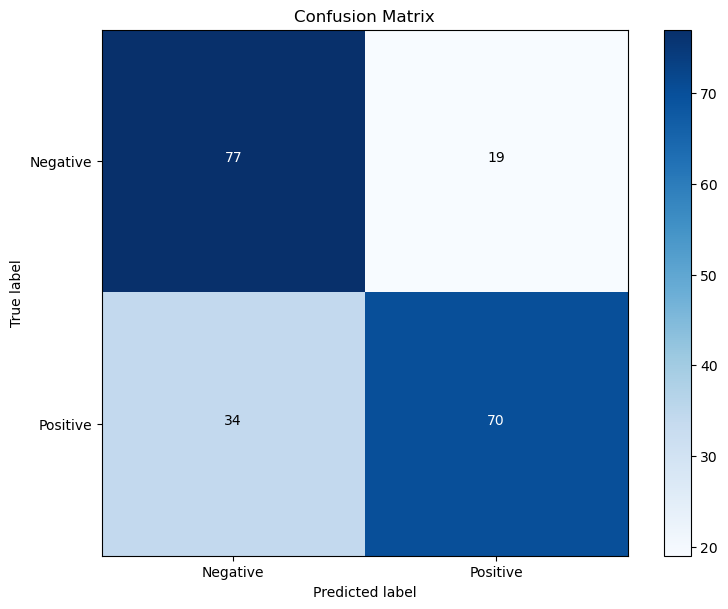

In [54]:
# 분류 문제이므로 분류 과정에서 많이 사용하는 평가 척도 사용

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)

# Confusion Matrix 시각화
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])

# 각 칸에 실제 값 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Precision, Recall, F1-Score 계산
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

# 결과 출력
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Accuracy: 0.73
Precision: 0.79
Recall: 0.67
F1-Score: 0.73


# 가상 데이터를 활용한 문장 분석 결과 확인

In [56]:
# 음식점에 대한 만족도 관련 텍스트를 임의로 생성

examples = [
    "This restaurant had the best service I've ever experienced.", # 긍정적
    "Extremely disappointed with the late delivery.", # 부정적
    "The ambiance was enchanting and very relaxing.", # 긍정적
    "Unfortunately, the food was bad and uninspired.", # 부정적
    "Amazing cocktails and a vibrant atmosphere!", # 긍정적
    "Waited an hour for our table, even with a reservation.", # 부정적
    "The pasta dish was a delightful surprise with its rich flavors.", # 긍정적
    "Too noisy to enjoy our meal, and the tables were too close together.", # 부정적
    "Exceptional customer service and a very friendly staff.", # 긍정적
    "The dessert was undercooked and not what we expected.", # 부정적
]

In [57]:
# 예제 문장 전처리
preprocessed_examples = [preprocessing(text) for text in examples]

# 원래 문장의 분포와 비슷한 문장들을 활용해 TF-IDF 메트릭스를 다시 생성하고
examples_vectorizer = TfidfVectorizer()
examples_tfidf_matrix = examples_vectorizer.fit_transform([' '.join(doc) for doc in preprocessed_examples])
examples_tfidf_feature_names = examples_vectorizer.get_feature_names_out()

# TF-IDF 값과 GloVe 임베딩을 결합하여 문장 임베딩 생성
example_sentence_embs = []
for doc_idx, doc in enumerate(preprocessed_examples):
    example_sentence_embs.append(sentence_embedding(examples_tfidf_matrix,
                                                    examples_tfidf_feature_names,
                                                    doc, doc_idx))

# 모델을 이용해 감정 분석 수행
example_sentence_embs = np.array(example_sentence_embs)
predictions = model.predict(example_sentence_embs)

# 결과 출력
for idx, (text, pred) in enumerate(zip(examples, predictions)):
    origin_sent = '긍정적' if idx % 2 == 0 else '부정적'
    pred_sent = '긍정적' if pred == 1 else '부정적'

    print(f"문장: {text} \n원래 감정 : {origin_sent} / 예측 : {pred_sent}", end='\n\n')

문장: This restaurant had the best service I've ever experienced. 
원래 감정 : 긍정적 / 예측 : 긍정적

문장: Extremely disappointed with the late delivery. 
원래 감정 : 부정적 / 예측 : 부정적

문장: The ambiance was enchanting and very relaxing. 
원래 감정 : 긍정적 / 예측 : 긍정적

문장: Unfortunately, the food was bad and uninspired. 
원래 감정 : 부정적 / 예측 : 부정적

문장: Amazing cocktails and a vibrant atmosphere! 
원래 감정 : 긍정적 / 예측 : 긍정적

문장: Waited an hour for our table, even with a reservation. 
원래 감정 : 부정적 / 예측 : 부정적

문장: The pasta dish was a delightful surprise with its rich flavors. 
원래 감정 : 긍정적 / 예측 : 긍정적

문장: Too noisy to enjoy our meal, and the tables were too close together. 
원래 감정 : 부정적 / 예측 : 긍정적

문장: Exceptional customer service and a very friendly staff. 
원래 감정 : 긍정적 / 예측 : 긍정적

문장: The dessert was undercooked and not what we expected. 
원래 감정 : 부정적 / 예측 : 부정적

